In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from lab.sinus_vs_square_hard.data import create_data
from quantum_learn.reservoir_computing import Reservoir
from quantum_learn import build_f
from quantum_simulation.configs import quantum_parameters, jpc_config_dudas
from quantum_simulation.jpc_chip import JPCChip

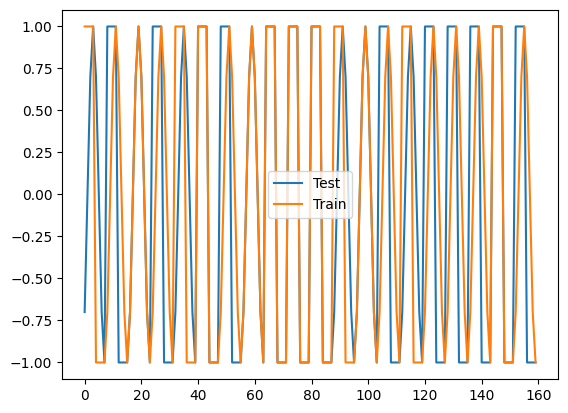

In [2]:
X_train, Y_train = create_data(20)
X_test, Y_test = create_data(20)

plt.plot(X_test, label="Test")
plt.plot(X_train, label="Train")
plt.legend()

In [3]:
jpc_config_dudas.summary()

JPCConfig(
    DIM_A=10,
    DIM_B=10,
    OMEGA_A=10000.0,
    OMEGA_B=9000.0,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=100
)


In [4]:
quantum_parameters = quantum_parameters
chip = JPCChip(jpc_config=jpc_config_dudas)

quantum_parameters.summary()

QuantumParameters(
    g_conv=900,
    g_sq=180,
    epsilon_a=170,
    epsilon_b=170,
    delta_a=0,
    delta_b=0
)


In [5]:
QRC_probas = Reservoir(
    build_f=build_f.BuildFPhotonDistribution(jpc_config=jpc_config_dudas, clip_probas=2))

QRC_quadratures = Reservoir(build_f=build_f.BuildFQuadratures(jpc_config=jpc_config_dudas))

QRC_quadratures_poly = Reservoir(
    build_f=build_f.BuildFQuadraturesPolynomials(jpc_config=jpc_config_dudas))


In [6]:
state_history_train = chip.run_simulation(X_train, [quantum_parameters])[0]

QRC_probas.fit(state_history=state_history_train, Y=Y_train)
QRC_quadratures.fit(state_history=state_history_train, Y=Y_train)
QRC_quadratures_poly.fit(state_history=state_history_train, Y=Y_train)

|██████████| 100.0% ◆ elapsed 04m40s ◆ remaining 0.00ms  
ERROR:2026-04-16 15:01:18,530:jax._src.callback:95: jax.pure_callback failed
Traceback (most recent call last):
  File "C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\jax\_src\callback.py", line 93, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
                                          ^^^^^^^^^^^^^^^
  File "C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\jax\_src\callback.py", line 71, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\equinox\_errors.py", line 88, in raises
    raise _EquinoxRuntimeError(
equinox._errors._EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during

XlaRuntimeError: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\jax\_src\callback.py", line 782, in _wrapped_callback
  File "C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\jax\_src\callback.py", line 222, in _callback
  File "C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\jax\_src\callback.py", line 96, in pure_callback_impl
  File "C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\jax\_src\callback.py", line 71, in __call__
  File "C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\equinox\_errors.py", line 88, in raises
_EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX program! Unfortunately you do not appear to be using `equinox.filter_jit` (perhaps you ar

In [ ]:
state_history_test = chip.run_simulation(X_test, [quantum_parameters])[0]

Y_probas = QRC_probas(state_history_test)
Y_quadratures = QRC_quadratures(state_history_test)
Y_quadratures_poly = QRC_quadratures_poly(state_history_test)

In [ ]:
threshold = 0.5
Y_corr_probas = Y_probas >= threshold
acc_probas = jnp.mean(Y_corr_probas == Y_test)
print("Accuracy probas = ", acc_probas * 1e2, "%")

Y_corr_quadratures = Y_quadratures >= threshold
acc_quadratures = jnp.mean(Y_corr_quadratures == Y_test)
print("Accuracy quadratures = ", acc_quadratures * 1e2, "%")

Y_corr_quadratures_poly = Y_quadratures_poly >= threshold
acc_quadratures_poly = jnp.mean(Y_corr_quadratures_poly == Y_test)
print("Accuracy quadratures poly = ", acc_quadratures_poly * 1e2, "%")

In [ ]:
X = range(len(Y_corr_probas))
plt.scatter(X, Y_corr_probas, label="QRC probas", color="b")
plt.scatter(X, Y_corr_quadratures, label="QRC quadratures", color="g")
plt.scatter(X, Y_corr_quadratures, label="QRC quadratures poly", color="k")
plt.plot(X, Y_test, label="Target", color="r")
plt.legend()
plt.show()